[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/somanshusingla/llm-from-scratch/blob/main/notebooks/07_appendix_extras.ipynb)

# Appendix — Bonus Upgrades (LoRA, LR Scheduling, Gradient Clipping)

**Build a Large Language Model (From Scratch)** · notebook 7 of 7 (optional)

Three practical techniques used in real LLM training, based on the book's
appendices D and E. Each is short, self-contained, and runs instantly on CPU.

1. **Learning-rate warmup + cosine decay** — a smarter learning-rate schedule.
2. **Gradient clipping** — stop exploding gradients from wrecking training.
3. **LoRA** — parameter-efficient fine-tuning (train <1% of the weights).

## 0. Setup

In [ ]:
import importlib, subprocess, sys
def ensure(pkg):
    try: importlib.import_module(pkg)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
ensure("matplotlib")

import math, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(123)
print("torch:", torch.__version__)

torch: 2.11.0+cu128


## 1. Learning-rate warmup + cosine decay (Appendix D)

A constant learning rate is rarely optimal. A common recipe:

- **Warmup**: start tiny and ramp up over the first few hundred steps so early,
  noisy gradients don't blow up the freshly-initialized weights.
- **Cosine decay**: after warmup, smoothly anneal the learning rate down toward a
  small minimum, which helps the model settle into a good minimum.

Let's compute and plot the schedule.

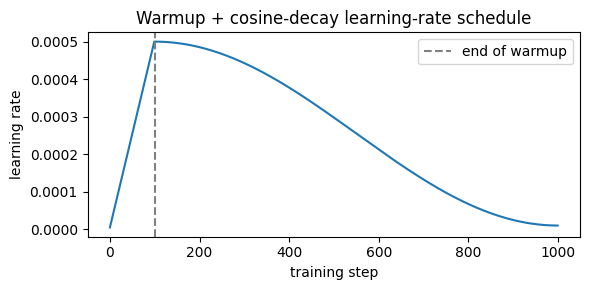

In [ ]:
def compute_lr(step, total_steps, warmup_steps, max_lr, min_lr):
    if step < warmup_steps:                       # linear warmup
        return max_lr * (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))  # cosine

total_steps, warmup_steps = 1000, 100
lrs = [compute_lr(s, total_steps, warmup_steps, max_lr=5e-4, min_lr=1e-5)
       for s in range(total_steps)]

plt.figure(figsize=(6, 3))
plt.plot(lrs)
plt.axvline(warmup_steps, color="gray", ls="--", label="end of warmup")
plt.xlabel("training step"); plt.ylabel("learning rate"); plt.legend()
plt.title("Warmup + cosine-decay learning-rate schedule"); plt.tight_layout(); plt.show()

## 2. Gradient clipping (Appendix D)

Sometimes a single batch produces huge gradients that send the weights flying.
**Gradient clipping** rescales the gradient vector so its norm never exceeds a
threshold — a cheap safety belt. One line: `clip_grad_norm_`.

Below, a tiny training loop combines **all three** ideas: per-step LR from the
schedule + gradient clipping. (We fit a trivial linear function so it runs
instantly and you can focus on the mechanics.)

In [ ]:
# toy problem: learn y = 3x + 2
X = torch.randn(256, 1)
y = 3 * X + 2 + 0.1 * torch.randn(256, 1)

model = nn.Linear(1, 1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1.0)  # lr is overwritten each step
loss_fn = nn.MSELoss()

steps, warmup = 300, 30
for step in range(steps):
    lr = compute_lr(step, steps, warmup, max_lr=0.1, min_lr=1e-3)
    for g in optimizer.param_groups:      # apply the scheduled LR
        g["lr"] = lr

    optimizer.zero_grad()
    loss = loss_fn(model(X), y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # <-- clipping
    optimizer.step()
    if step % 60 == 0:
        print(f"step {step:3d} | lr {lr:.4f} | loss {loss.item():.4f}")

w, b = model.weight.item(), model.bias.item()
print(f"\nLearned  y = {w:.2f}x + {b:.2f}   (target was y = 3x + 2)")

step   0 | lr 0.0033 | loss 16.0050
step  60 | lr 0.0970 | loss 0.0289
step 120 | lr 0.0753 | loss 0.0099
step 180 | lr 0.0419 | loss 0.0100
step 240 | lr 0.0126 | loss 0.0099



Learned  y = 3.00x + 2.00   (target was y = 3x + 2)


## 3. LoRA — Low-Rank Adaptation (Appendix E)

Fully fine-tuning a big model updates *all* its weights — lots of memory and
compute. **LoRA** freezes the original weights and learns a tiny **low-rank**
correction `alpha * (x @ A @ B)` alongside each linear layer. Only `A` and `B`
train — a small fraction of the parameters (on a full transformer this is
typically **well under 1%**; on the tiny toy net below it's larger because the
layers themselves are small) — yet it often matches full fine-tuning.

`B` is initialized to zeros, so at the start the LoRA update is 0 and the model
behaves exactly like the pretrained one.

In [ ]:
class LoRALayer(nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = nn.Parameter(torch.empty(in_dim, rank))
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = nn.Parameter(torch.zeros(rank, out_dim))  # start at zero -> no-op initially
        self.alpha = alpha
    def forward(self, x):
        return self.alpha * (x @ self.A @ self.B)

class LinearWithLoRA(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear                                   # frozen original
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)
    def forward(self, x):
        return self.linear(x) + self.lora(x)                   # original + low-rank update

def replace_linear_with_lora(module, rank, alpha):
    for name, child in module.named_children():
        if isinstance(child, nn.Linear):
            setattr(module, name, LinearWithLoRA(child, rank, alpha))
        else:
            replace_linear_with_lora(child, rank, alpha)

In [ ]:
# A small stand-in "model" (a few linear layers, like the ones inside a transformer)
base = nn.Sequential(
    nn.Linear(128, 256), nn.GELU(),
    nn.Linear(256, 256), nn.GELU(),
    nn.Linear(256, 10),
)
total_before = sum(p.numel() for p in base.parameters())

# 1) freeze ALL original weights
for p in base.parameters():
    p.requires_grad = False

# 2) inject LoRA into every linear layer (its A,B are trainable by default)
replace_linear_with_lora(base, rank=8, alpha=16)

trainable = sum(p.numel() for p in base.parameters() if p.requires_grad)
print(f"Total parameters      : {total_before:,}")
print(f"Trainable with LoRA   : {trainable:,}  ({100*trainable/total_before:.2f}% of the model)")

Total parameters      : 101,386
Trainable with LoRA   : 9,296  (9.17% of the model)


In [ ]:
# Confirm only LoRA A/B tensors are trainable, and that training actually updates them.
before = base[0].lora.B.detach().clone()

opt = torch.optim.AdamW([p for p in base.parameters() if p.requires_grad], lr=1e-3)
x = torch.randn(16, 128)
target = torch.randint(0, 10, (16,))
for _ in range(20):
    opt.zero_grad()
    loss = nn.functional.cross_entropy(base(x), target)
    loss.backward()
    opt.step()

moved = not torch.allclose(before, base[0].lora.B)
print("LoRA weights updated during training:", moved)
print("Final loss:", round(loss.item(), 3))
print("\nTo LoRA-fine-tune the GPT model from earlier chapters, you'd freeze it and")
print("call replace_linear_with_lora(model, rank=..., alpha=...) -- same idea, bigger net.")

LoRA weights updated during training: True
Final loss: 0.0

To LoRA-fine-tune the GPT model from earlier chapters, you'd freeze it and
call replace_linear_with_lora(model, rank=..., alpha=...) -- same idea, bigger net.


## Summary

- **Warmup + cosine decay** stabilizes early training and anneals the LR for a
  better final model.
- **Gradient clipping** (`clip_grad_norm_`) prevents rare huge gradients from
  derailing training.
- **LoRA** fine-tunes a model by training a tiny low-rank add-on, cutting
  trainable parameters to a fraction of the whole.

These are the kinds of "bells and whistles" used to train and adapt real LLMs
efficiently — and you can drop them straight into the training loops from
chapters 5–7.

**You've reached the end of the course — congratulations on building an LLM from
scratch!** 🎉